Dataset Shape:
(7043, 21)

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

/tmp/ipykernel_418/3127993556.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7566 - loss: 0.4876 - val_accuracy: 0.7799 - val_loss: 0.4329
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7890 - loss: 0.4332 - val_accuracy: 0.8012 - val_loss: 0.4159
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7974 - loss: 0.4220 - val_accuracy: 0.8101 - val_loss: 0.4164
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7988 - loss: 0.4163 - val_accuracy: 0.7986 - val_loss: 0.4179
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8076 - loss: 0.4115 - val_accuracy: 0.8030 - val_loss: 0.4151
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8072 - loss: 0.4055 - val_accuracy: 0.7924 - val_loss: 0.4177
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8161 - loss: 0.4015 - val_accuracy: 0.8021 - val_loss: 0.4173
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8172 - loss: 0.3971 - val_accuracy: 0.

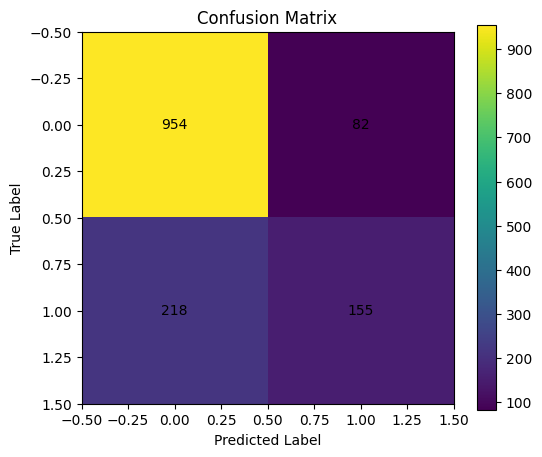

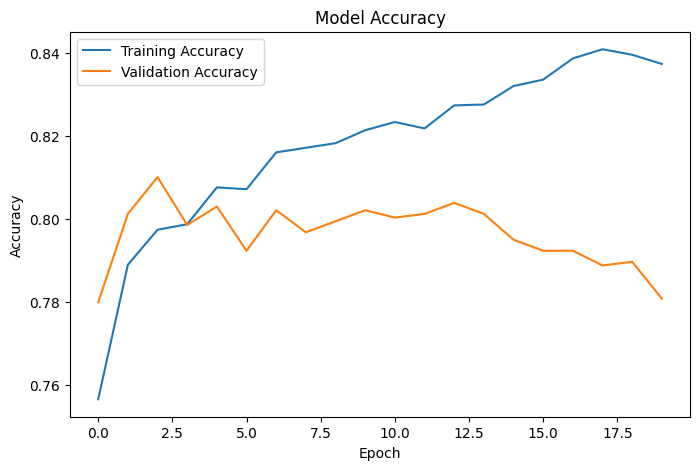

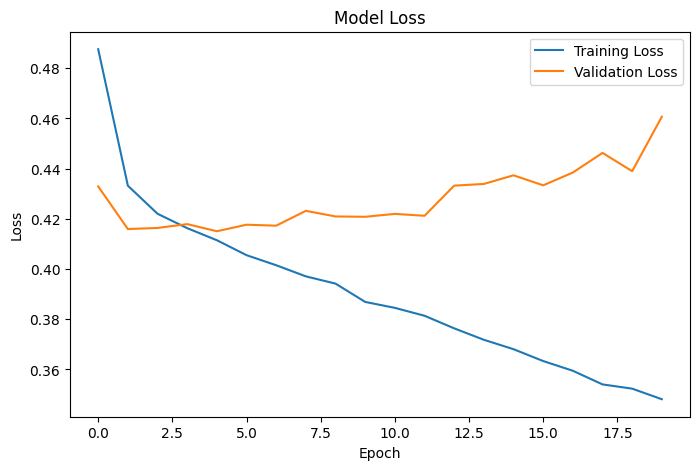

In [1]:
#Parambrata Sanyal - 23070521101

# ============================================================
# Customer Churn Classification using Deep Feed Forward Network

# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# ============================================================
# STEP 2: LOAD THE DATASET
# ============================================================

# Upload the CSV file to Google Colab and provide its path

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# STEP 3: CHECK FOR MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# STEP 4: HANDLE 'TotalCharges' COLUMN
# ============================================================

# Convert TotalCharges from object to numeric.
# Blank values will become NaN.

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Replace NaN values with the median.

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)


# ============================================================
# STEP 5: REMOVE UNNECESSARY COLUMN
# ============================================================

# customerID is only an identifier and is not useful
# for prediction.

df.drop('customerID', axis=1, inplace=True)


# ============================================================
# STEP 6: ENCODE CATEGORICAL VARIABLES
# ============================================================

# Convert all text columns into numerical values.

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

print("\nEncoded Dataset:")
print(df.head())


# ============================================================
# STEP 7: SPLIT FEATURES AND TARGET VARIABLE
# ============================================================

# X -> Input Features
# y -> Target Variable (Churn)

X = df.drop('Churn', axis=1)
y = df['Churn']


# ============================================================
# STEP 8: TRAIN-TEST SPLIT
# ============================================================

# 80% Training Data
# 20% Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])


# ============================================================
# STEP 9: FEATURE SCALING
# ============================================================

# Standardization improves Deep Learning performance.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# STEP 10: BUILD DEEP FEED FORWARD NETWORK
# ============================================================

# Architecture:
#
# Input Layer
#      ↓
# Dense(64)
#      ↓
# Dense(32)
#      ↓
# Dense(16)
#      ↓
# Output Layer

model = Sequential()

# First Hidden Layer
model.add(
    Dense(
        64,
        activation='relu',
        input_dim=X_train.shape[1]
    )
)

# Second Hidden Layer
model.add(
    Dense(
        32,
        activation='relu'
    )
)

# Third Hidden Layer
model.add(
    Dense(
        16,
        activation='relu'
    )
)

# Output Layer
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)


# ============================================================
# STEP 11: COMPILE THE MODEL
# ============================================================

# Adam Optimizer
# Binary Crossentropy Loss
# Accuracy Metric

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary:")
model.summary()


# ============================================================
# STEP 12: TRAIN THE MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# ============================================================
# STEP 13: EVALUATE THE MODEL
# ============================================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy:", round(accuracy * 100, 2), "%")


# ============================================================
# STEP 14: MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# Convert probabilities into 0 or 1

y_pred = (y_pred > 0.5).astype(int)


# ============================================================
# STEP 15: CALCULATE ACCURACY
# ============================================================

acc = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(round(acc * 100, 2), "%")


# ============================================================
# STEP 16: GENERATE CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# STEP 17: CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# STEP 18: VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

# Add values inside matrix cells

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(
            j,
            i,
            str(cm[i][j]),
            ha='center',
            va='center'
        )

plt.show()


# ============================================================
# STEP 19: PLOT TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(
    ['Training Accuracy', 'Validation Accuracy']
)

plt.show()


# ============================================================
# STEP 20: PLOT TRAINING LOSS
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(
    ['Training Loss', 'Validation Loss']
)

plt.show()


# ============================================================
# FINAL OUTPUTS
# ============================================================
#
# 1. Test Accuracy
# 2. Confusion Matrix
# 3. Classification Report
# 4. Training Accuracy Graph
# 5. Training Loss Graph
#
# Expected Accuracy:
# Approximately 78% - 82%
#
# ============================================================